In [ ]:
print("Hello, world!")

Hello, world!


In [2]:
import jax.numpy as jnp
from flax import nnx
import time

In [3]:
class ResNetBlock(nnx.Module):
    def __init__(self, channels: int, rngs: nnx.Rngs):
        # Keeps channels constant to allow direct addition
        self.conv1 = nnx.Conv(channels, channels, kernel_size=(3, 3), padding='SAME', rngs=rngs)
        self.bn1 = nnx.BatchNorm(channels, rngs=rngs)
        self.conv2 = nnx.Conv(channels, channels, kernel_size=(3, 3), padding='SAME', rngs=rngs)
        self.bn2 = nnx.BatchNorm(channels, rngs=rngs)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        residual = x
        
        # Main processing branch
        y = nnx.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))
        
        # Element-wise addition: reuses existing memory shape
        return nnx.relu(y + residual)

In [4]:
class DenseNetBlock(nnx.Module):
    def __init__(self, in_channels: int, growth_rate: int, rngs: nnx.Rngs):
        self.bn1 = nnx.BatchNorm(in_channels, rngs=rngs)
        # Only generates a small number of new features (growth_rate)
        self.conv1 = nnx.Conv(in_channels, growth_rate, kernel_size=(3, 3), padding='SAME', rngs=rngs)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # Bottleneck/Processing step
        y = nnx.relu(self.bn1(x))
        new_features = self.conv1(y)
        
        # Concatenation: forces allocation of a new, larger tensor block
        return jnp.concatenate([x, new_features], axis=-1)

# Profiling with Larger Input Tensor

In [6]:
# 1. Setup dimensions for larger input
# Using the same constants from the original benchmark, but increasing B, H, W
B_large, H_large, W_large, C_large = 64, 128, 128, 64 # Increased B, H, W
growth_rate_large = 32
num_warmups_large = 10
num_repeats_large = 100

# Initialize keys and input data with new dimensions
rngs_large = nnx.Rngs(43) # Use a different seed for the new run
x_large = jnp.ones((B_large, H_large, W_large, C_large))

# Re-initialize our modules with new dimensions
# It's important to re-initialize the modules for the new tensor shape
resnet_block_large = ResNetBlock(channels=C_large, rngs=rngs_large)
densenet_block_large = DenseNetBlock(in_channels=C_large, growth_rate=growth_rate_large, rngs=rngs_large)

# 2. Define JIT-compiled execution functions (these are the same as before)
@nnx.jit
def profile_resnet_large(module: ResNetBlock, tensor: jnp.ndarray):
    return module(tensor)

@nnx.jit
def profile_densenet_large(module: DenseNetBlock, tensor: jnp.ndarray):
    return module(tensor)

# Define run_benchmark (same function as before, but operating on new variables)
def run_benchmark_large(name, module_instance, jit_fn, init_tensor):
    print(f"\n--- Profiling {name} (Larger Input) ---")

    # --- COLD RUN (Measures Compilation + First Execution) ---
    start = time.perf_counter()
    out = jit_fn(module_instance, init_tensor)
    out.block_until_ready()  # Force synchronous wait
    cold_time = time.perf_counter() - start
    print(f"Cold Run (Compile Time included): {cold_time:.4f} seconds")

    # Warmup steps to clear any caching artifacts
    for _ in range(num_warmups_large):
        jit_fn(module_instance, init_tensor).block_until_ready()

    # --- WARM RUNS (Measures Pure Execution Speed) ---
    start = time.perf_counter()
    for _ in range(num_repeats_large):
        jit_fn(module_instance, init_tensor).block_until_ready()
    warm_time = (time.perf_counter() - start) / num_repeats_large
    print(f"Warm Run Average (Pure Execution):  {warm_time * 1000:.4f} ms")

# Run both benchmarks with larger input
run_benchmark_large("ResNet Block (Addition)", resnet_block_large, profile_resnet_large, x_large)
run_benchmark_large("DenseNet Block (Concatenation)", densenet_block_large, profile_densenet_large, x_large)


--- Profiling ResNet Block (Addition) (Larger Input) ---
Cold Run (Compile Time included): 2.9009 seconds
Warm Run Average (Pure Execution):  41.2135 ms

--- Profiling DenseNet Block (Concatenation) (Larger Input) ---
Cold Run (Compile Time included): 1.2248 seconds
Warm Run Average (Pure Execution):  14.6265 ms


In [7]:
import matplotlib.pyplot as plt

Starting multi-size benchmark...
Benchmarking B=32, H=32, W=32, C=64...
Benchmarking B=32, H=64, W=64, C=64...
Benchmarking B=32, H=96, W=96, C=64...
Benchmarking B=32, H=128, W=128, C=64...
Benchmarking B=32, H=160, W=160, C=64...
Benchmarking B=32, H=192, W=192, C=64...
Benchmark complete. Plotting results...


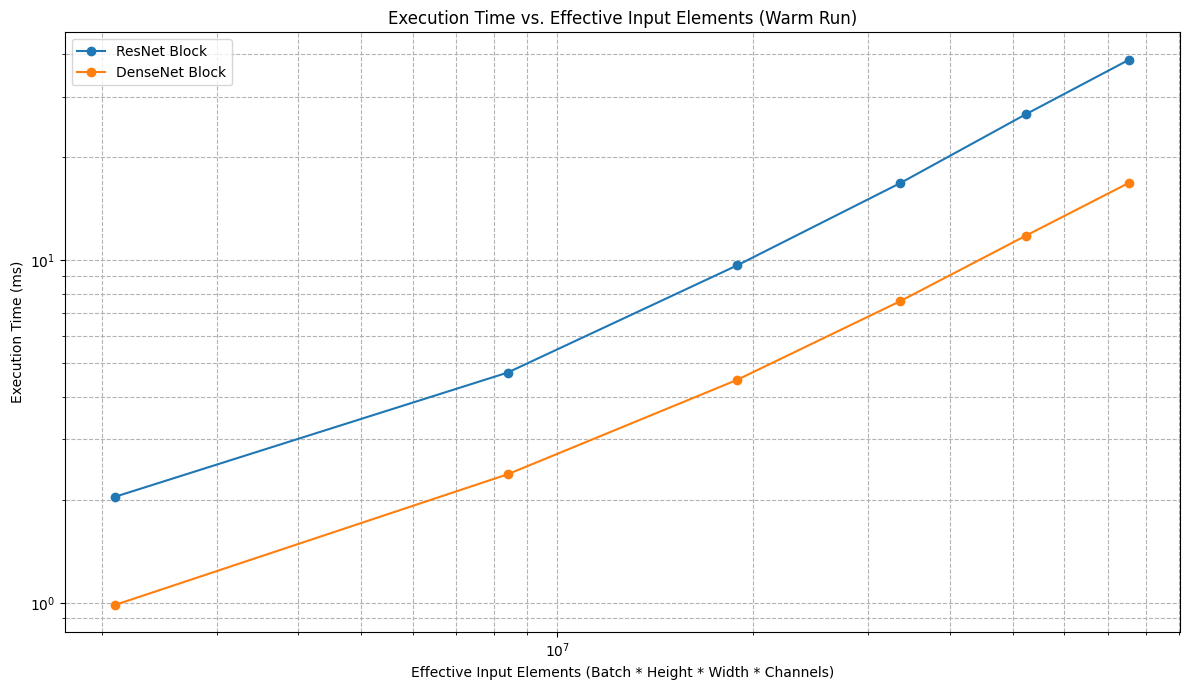


--- Collected Data ---
Input Config (B,H,W,C): (32, 32, 32, 64), Effective Elements: 2,097,152, ResNet Time: 2.04ms, DenseNet Time: 0.99ms
Input Config (B,H,W,C): (32, 64, 64, 64), Effective Elements: 8,388,608, ResNet Time: 4.70ms, DenseNet Time: 2.37ms
Input Config (B,H,W,C): (32, 96, 96, 64), Effective Elements: 18,874,368, ResNet Time: 9.67ms, DenseNet Time: 4.48ms
Input Config (B,H,W,C): (32, 128, 128, 64), Effective Elements: 33,554,432, ResNet Time: 16.79ms, DenseNet Time: 7.59ms
Input Config (B,H,W,C): (32, 160, 160, 64), Effective Elements: 52,428,800, ResNet Time: 26.75ms, DenseNet Time: 11.82ms
Input Config (B,H,W,C): (32, 192, 192, 64), Effective Elements: 75,497,472, ResNet Time: 38.59ms, DenseNet Time: 16.87ms


In [8]:
# Helper function to get warm run time for plotting
def get_warm_run_time(module_instance, jit_fn, init_tensor, num_warmups=10, num_repeats=100):
    # Warmup steps
    for _ in range(num_warmups):
        jit_fn(module_instance, init_tensor).block_until_ready()

    # WARM RUNS (Measures Pure Execution Speed)
    start = time.perf_counter()
    for _ in range(num_repeats):
        jit_fn(module_instance, init_tensor).block_until_ready()
    warm_time = (time.perf_counter() - start) / num_repeats
    return warm_time * 1000 # Return in ms

# Define JIT-compiled execution functions (assuming they are defined in previous cells and accessible)
@nnx.jit
def profile_resnet_plot(module: ResNetBlock, tensor: jnp.ndarray):
    return module(tensor)

@nnx.jit
def profile_densenet_plot(module: DenseNetBlock, tensor: jnp.ndarray):
    return module(tensor)

# Define a range of input tensor sizes (B, H, W, C)
# Varying H and W to see scaling, keeping B and C constant for simplicity
input_configs = [
    (32, 32, 32, 64),
    (32, 64, 64, 64),
    (32, 96, 96, 64),
    (32, 128, 128, 64),
    (32, 160, 160, 64),
    (32, 192, 192, 64)
]

resnet_times = []
densenet_times = []
effective_input_elements = [] # To represent input size on x-axis (B * H * W * C)

print("Starting multi-size benchmark...")
for B, H, W, C in input_configs:
    # Re-initialize modules for each size with a fresh RNG
    rngs_current = nnx.Rngs(42) # Use same seed for consistency across runs
    resnet_block_current = ResNetBlock(channels=C, rngs=rngs_current)
    densenet_block_current = DenseNetBlock(in_channels=C, growth_rate=32, rngs=rngs_current)

    x_current = jnp.ones((B, H, W, C))

    print(f"Benchmarking B={B}, H={H}, W={W}, C={C}...")

    # Get warm run time for ResNet
    resnet_warm_time = get_warm_run_time(resnet_block_current, profile_resnet_plot, x_current)
    resnet_times.append(resnet_warm_time)

    # Get warm run time for DenseNet
    densenet_warm_time = get_warm_run_time(densenet_block_current, profile_densenet_plot, x_current)
    densenet_times.append(densenet_warm_time)

    effective_input_elements.append(B * H * W * C)

print("Benchmark complete. Plotting results...")

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(effective_input_elements, resnet_times, marker='o', linestyle='-', label='ResNet Block')
plt.plot(effective_input_elements, densenet_times, marker='o', linestyle='-', label='DenseNet Block')
plt.title('Execution Time vs. Effective Input Elements (Warm Run)')
plt.xlabel('Effective Input Elements (Batch * Height * Width * Channels)')
plt.ylabel('Execution Time (ms)')
plt.xscale('log') # Use log scale for x-axis if sizes vary widely
plt.yscale('log') # Use log scale for y-axis if times vary widely
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()

# Print collected data for verification
print("\n--- Collected Data ---")
for i, config in enumerate(input_configs):
    print(f"Input Config (B,H,W,C): {config}, Effective Elements: {effective_input_elements[i]:,}, ResNet Time: {resnet_times[i]:.2f}ms, DenseNet Time: {densenet_times[i]:.2f}ms")